# 3-Step Grid Search: Model Class Comparison

Compare three model classes from the (σ₀, σ₁, σ₂) grid search against the human d' curve:
1. **3-step**: σ₀ > 0 and σ₁ > σ₂ (encoding noise + two-regime drift)
2. **2-step**: σ₀ = 0 and σ₁ > σ₂ (no encoding noise, two-regime drift)
3. **Constant noise**: σ₀ = 0 and σ₁ = σ₂ (single diffusion rate)

Only models satisfying σ₀ ≥ σ₁ ≥ σ₂ are considered.

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Results directory ──
RESULTS_DIR = (
    '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t4_nmc1_task0'
)

#/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t5_nmc1_task0/
# ── Load merged grid search results ──
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_3step_t5.npz'))
sigma0_grid = grid['sigma0_grid']
sigma1_grid = grid['sigma1_grid']
sigma2_grid = grid['sigma2_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

# 3D d' arrays: results[isi][i_s0, i_s1, i_s2]
results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# ── Flatten into DataFrame ──
rows = []
for i0, s0 in enumerate(sigma0_grid):
    for i1, s1 in enumerate(sigma1_grid):
        for i2, s2 in enumerate(sigma2_grid):
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2,
                   'i_s0': i0, 'i_s1': i1, 'i_s2': i2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = results[isi][i0, i1, i2]
            rows.append(row)

df = pd.DataFrame(rows)
print(f'Total grid points: {len(df)}')
print(f'Grid: {len(sigma0_grid)} x {len(sigma1_grid)} x {len(sigma2_grid)}')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma1: {sigma1_grid}')
print(f'sigma2: {sigma2_grid}')

Total grid points: 3375
Grid: 15 x 15 x 15
ISI values: (0, 1, 2, 4, 8, 16, 32, 64)
sigma0: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma1: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma2: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]


In [8]:
# ── Load human d' curve ──
from utls.runners_utils import load_experiment_data, compute_human_curve
from utls.analysis_helpers import roc_for_isi, auroc_to_dprime

which_task = 0   # first multi-ISI task
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

# Human curve ISIs for is_multi: [0, 1, 2, 4, 8, 16, 32, 64]
human_isis_full = np.array([0, 1, 2, 4, 8, 16, 32, 64])
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)

# Grid ISIs (from npz) may not include ISI=3 — align to grid
grid_isis = np.array(ISI_VALUES)
mask = np.isin(human_isis_full, grid_isis)
human_dp = human_curve_full[mask]
isis = human_isis_full[mask]

assert len(human_dp) == len(grid_isis), (
    f'Mismatch: human has {len(human_dp)} ISIs, grid has {len(grid_isis)}'
)

# ── Compute per-participant d' → SEM ──
per_subj = []
for run in human_runs:
    row = []
    for isi_val in grid_isis:
        res = roc_for_isi(run, isi_val)
        row.append(auroc_to_dprime(res[2]) if res is not None else np.nan)
    per_subj.append(row)
human_dp_mat = np.array(per_subj)  # (N_participants, N_isi)
n_valid = np.sum(~np.isnan(human_dp_mat), axis=0)
human_sem = np.nanstd(human_dp_mat, axis=0, ddof=1) / np.sqrt(n_valid)

print(f'Task: {hr_task_name} ({task_name})')
print(f'Human participants: {len(human_runs)}')
print(f'Aligned ISIs: {isis}')
print(f'Human d\': {np.round(human_dp, 3)}')
print(f'Human SEM: {np.round(human_sem, 3)}')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Industrial and Nature (env-sounds)
Human participants: 104
Aligned ISIs: [ 0  1  2  4  8 16 32 64]
Human d': [3.501 3.036 2.413 2.2   2.031 1.914 1.775 1.598]
Human SEM: [0.147 0.136 0.099 0.106 0.095 0.083 0.069 0.084]


PARAMETRIC FIT RESULTS
  d'(t) = 1.93 * (t + 0.90)^(-0.577) + 1.48
  a     = 1.927 ± 0.769
  α     = 0.577 ± 0.417
  t0    = 0.898 ± 0.911
  d_inf = 1.485 ± 0.295
  R²    = 0.9789

  Implied noise exponent: σ²(t) ~ t^(0.154)
  → Noise ACCELERATES

  Δ (self-consistent) = 3.535
  σ²(t=1)  = 0.4533
  σ²(t=10) = 0.0841
  σ²(t=30) = 0.0232

  Max reconstruction error: 6.32e-02
  (should be ~0 if inversion is self-consistent)


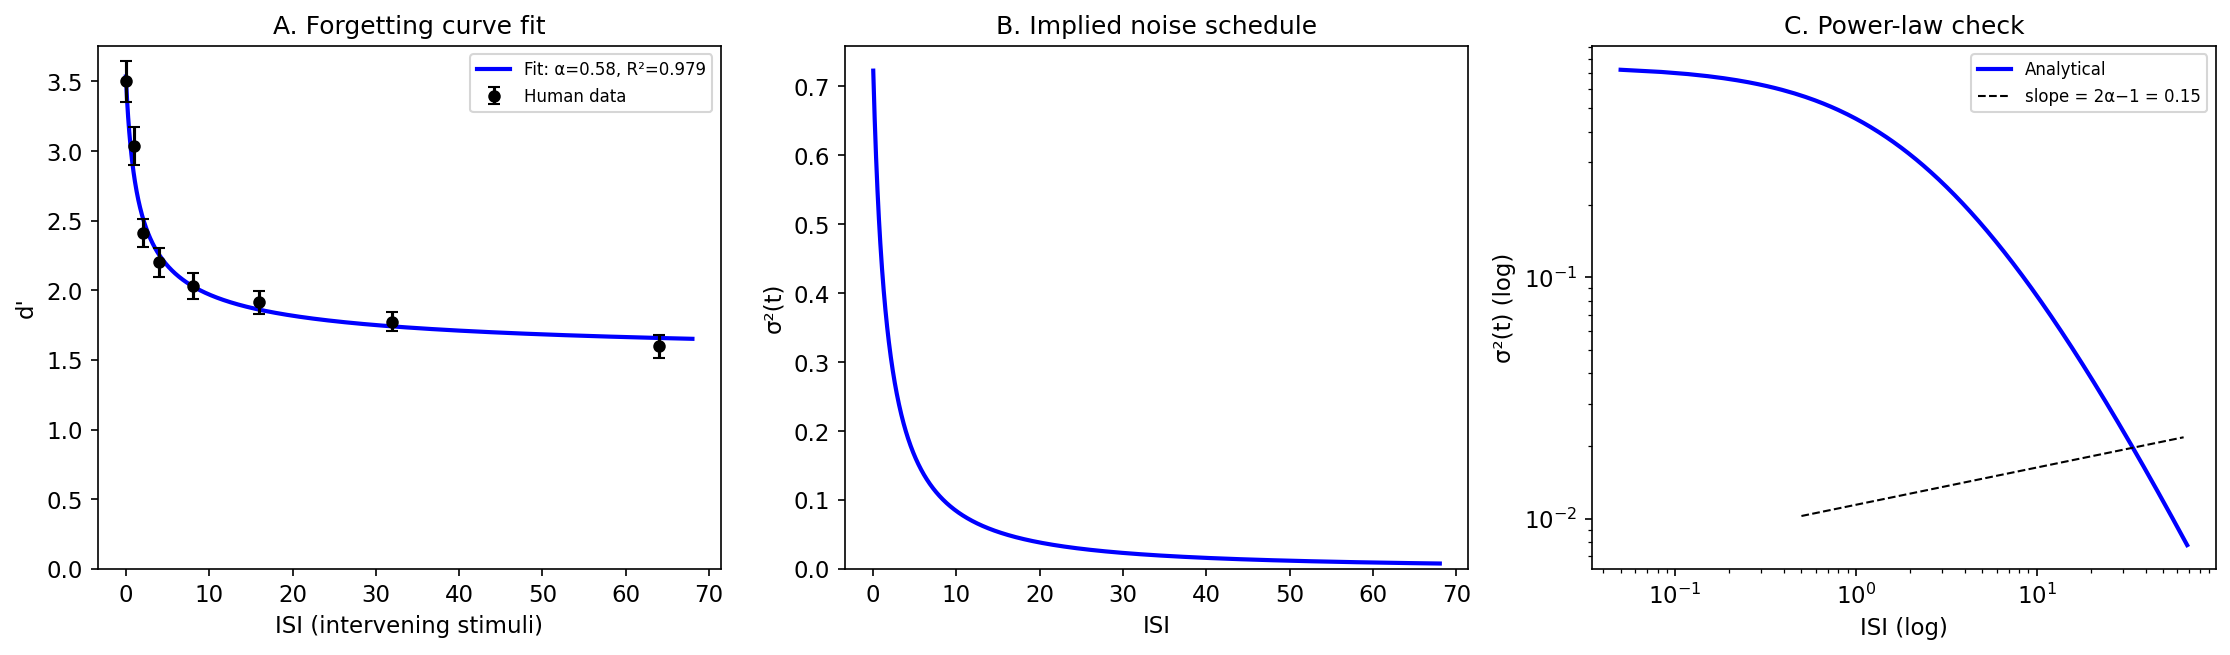

Saved: fig1_noise_inversion.png


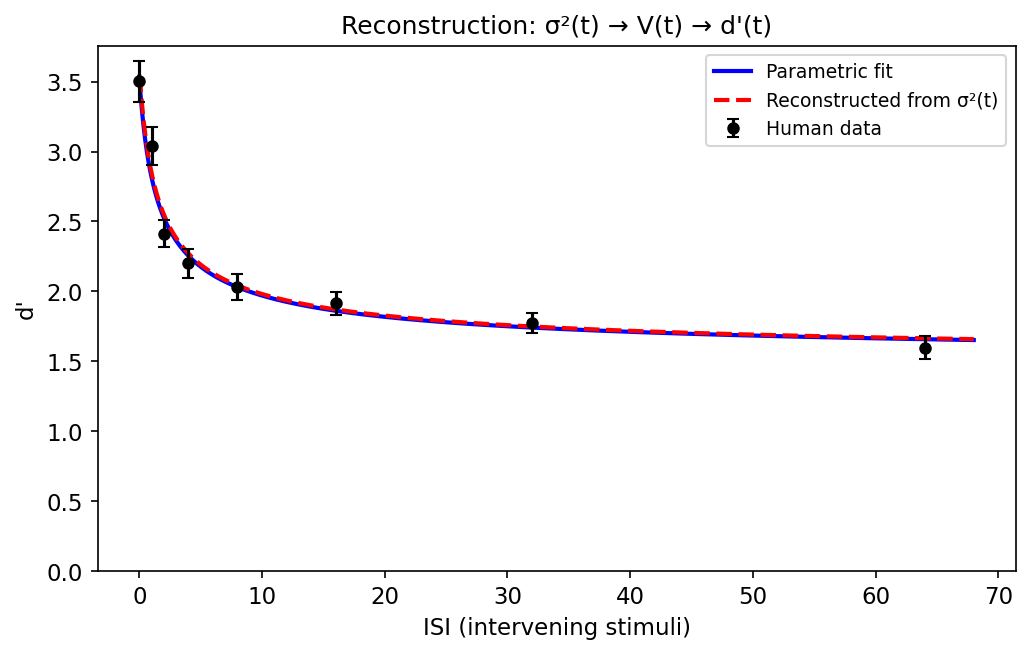

Saved: fig2_reconstruction.png


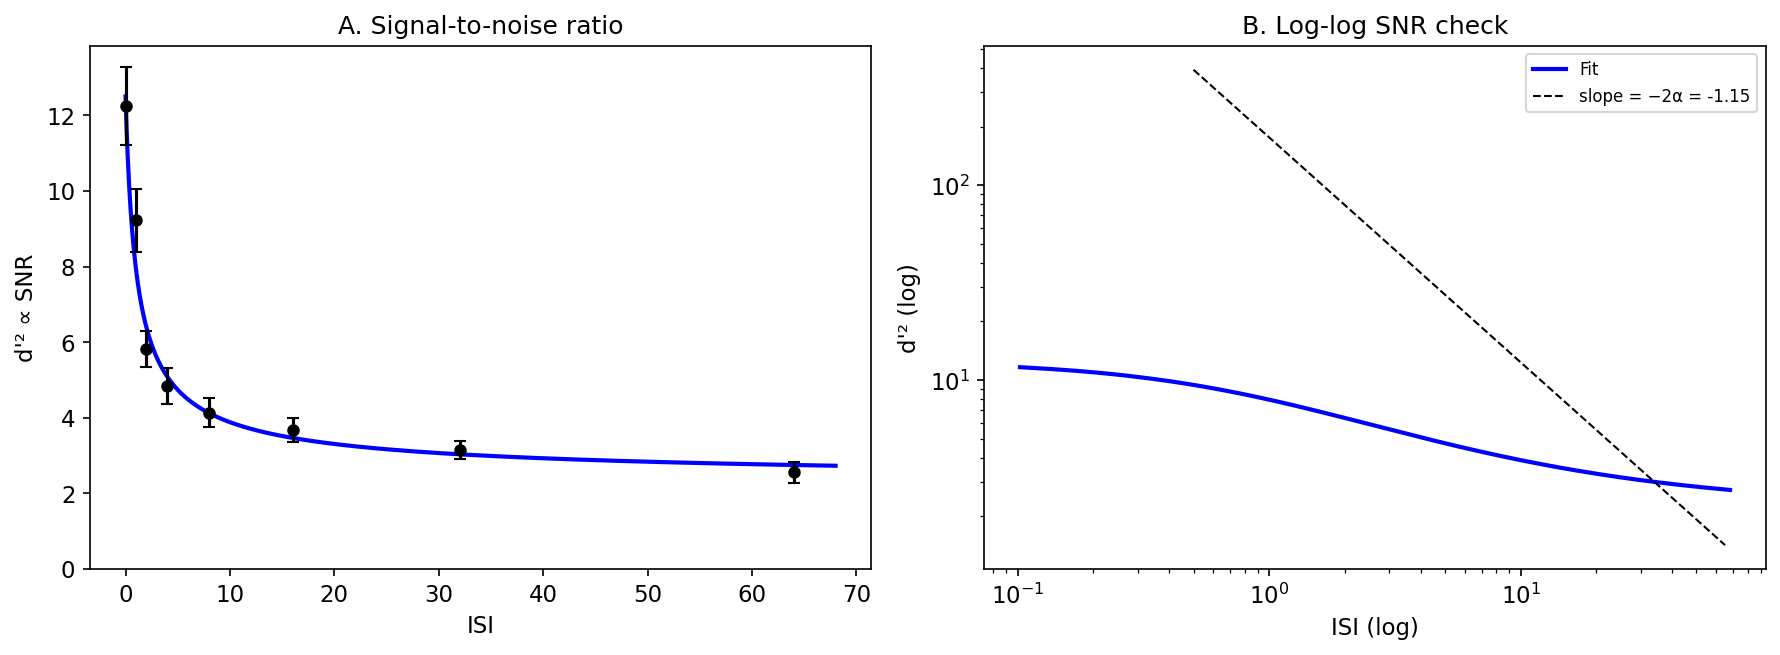

Saved: fig3_snr.png


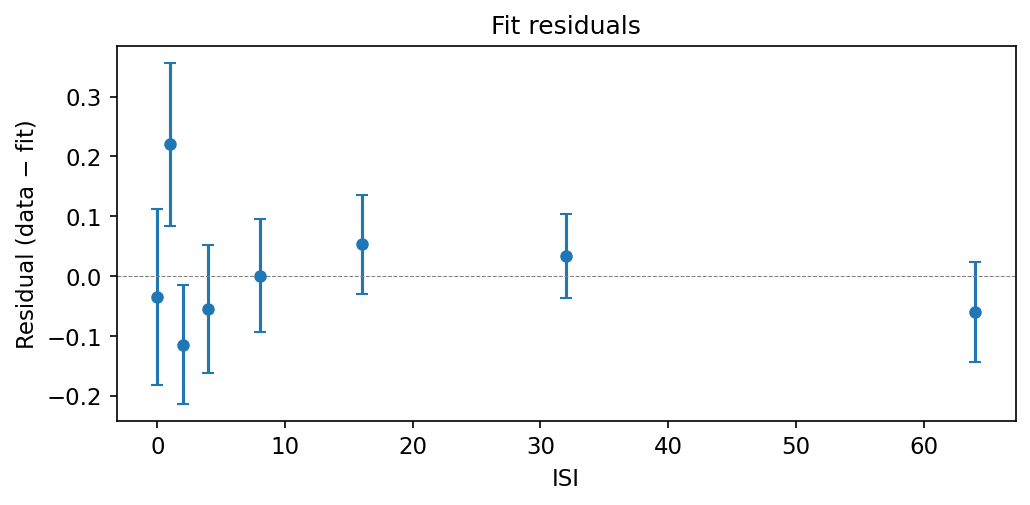

Saved: fig4_residuals.png

LOG-LOG SLOPE DIAGNOSTIC
  Measured slope (t > 8): -1.252
  Expected (2α−1):              0.154
  Discrepancy:                   1.406
  ! Discrepancy likely from d_inf floor or t0 offset

SUMMARY

  Forgetting curve:
    d'(t) = 1.93·(t + 0.90)^(-0.577) + 1.48
    α = 0.577 ± 0.417,  R² = 0.9789

  Noise schedule:
    σ²(t) ~ t^(0.154)  [accelerating]

  Normalization:
    Δ = 3.535,  σ₀ = 1  (self-consistent units)

  Reconstruction max error: 6.32e-02

  Figures saved:
    fig1_noise_inversion.png  — main 3-panel result
    fig2_reconstruction.png   — round-trip validation
    fig3_snr.png              — SNR analysis
    fig4_residuals.png        — fit residuals


In [12]:
# %% [markdown]
# # Noise Schedule Inversion: Proof of Concept
#
# Recovers the implied noise schedule σ²(t) from the human forgetting curve
# using the closed-form SDT inversion:
#
# ```
# d'(t) = Δ / sqrt(σ₀² + V(t))
# => σ²(t) = -2Δ² · ḋ'(t) / d'(t)³
# ```
#
# Produces a 3-panel figure + reconstruction validation + SNR analysis.

# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

# ============================================================
# UPDATE THESE WITH YOUR ACTUAL DATA
# ============================================================

isi_values = np.array([0, 1, 2, 4, 8, 16, 32, 64])

# Human d' for environmental sounds — REPLACE with real values
dprime_human = human_dp
dprime_sem = human_sem


# ============================================================
# PARAMETRIC FIT
# ============================================================

# %%
def powerlaw_floor(t, a, alpha, t0, d_inf):
    """d'(t) = a * (t + t0)^{-α} + d_inf"""
    return a * (t + t0) ** (-alpha) + d_inf

def powerlaw_floor_deriv(t, a, alpha, t0, d_inf):
    """Analytical derivative ḋ'(t)."""
    return -a * alpha * (t + t0) ** (-alpha - 1)

# Fit
popt, pcov = curve_fit(
    powerlaw_floor, isi_values, dprime_human,
    p0=[2.0, 0.3, 1.0, 0.5],
    sigma=dprime_sem, absolute_sigma=True,
    bounds=([0, 0.01, 0.1, 0], [20, 2.0, 20, 5.0]),
)
a, alpha, t0, d_inf = popt
perr = np.sqrt(np.diag(pcov))

# Fit quality
dp_pred = powerlaw_floor(isi_values, *popt)
residuals = dprime_human - dp_pred
ss_res = np.sum((residuals / dprime_sem) ** 2)
ss_tot = np.sum(((dprime_human - np.mean(dprime_human)) / dprime_sem) ** 2)
r_sq = 1 - ss_res / ss_tot

print("=" * 50)
print("PARAMETRIC FIT RESULTS")
print("=" * 50)
print(f"  d'(t) = {a:.2f} * (t + {t0:.2f})^(-{alpha:.3f}) + {d_inf:.2f}")
print(f"  a     = {a:.3f} ± {perr[0]:.3f}")
print(f"  α     = {alpha:.3f} ± {perr[1]:.3f}")
print(f"  t0    = {t0:.3f} ± {perr[2]:.3f}")
print(f"  d_inf = {d_inf:.3f} ± {perr[3]:.3f}")
print(f"  R²    = {r_sq:.4f}")
print(f"\n  Implied noise exponent: σ²(t) ~ t^({2*alpha - 1:.3f})")
if 2 * alpha - 1 < 0:
    print("  → Noise DECELERATES (consolidation-like)")
elif 2 * alpha - 1 > 0:
    print("  → Noise ACCELERATES")
else:
    print("  → Constant noise (standard Brownian motion)")


# ============================================================
# INVERSION: recover σ²(t)
# ============================================================

# %%
# Self-consistent normalization: σ₀ = 1, Δ = d'(0)
sigma0_sq = 1.0
Delta = powerlaw_floor(0, *popt) * np.sqrt(sigma0_sq)

# Fine time grids
t_fine = np.linspace(0, 68, 2000)          # for plotting the fit
t_inv = np.linspace(0.05, 68, 2000)        # for inversion (avoid t=0)

# Forgetting curve on fine grid
dp_fit = powerlaw_floor(t_fine, *popt)

# Inversion quantities
dp_inv = powerlaw_floor(t_inv, *popt)
dp_dot_inv = powerlaw_floor_deriv(t_inv, *popt)

# Cumulative variance: V(t) = Δ² / d'(t)² - σ₀²
V_analytical = Delta**2 / dp_inv**2 - sigma0_sq
V_analytical = np.maximum(V_analytical, 0)

# Instantaneous noise schedule: σ²(t) = -2Δ² · ḋ'(t) / d'(t)³
sigma_sq = -2 * Delta**2 * dp_dot_inv / dp_inv**3

print(f"\n  Δ (self-consistent) = {Delta:.3f}")
print(f"  σ²(t=1)  = {np.interp(1, t_inv, sigma_sq):.4f}")
print(f"  σ²(t=10) = {np.interp(10, t_inv, sigma_sq):.4f}")
print(f"  σ²(t=30) = {np.interp(30, t_inv, sigma_sq):.4f}")


# ============================================================
# RECONSTRUCTION: plug σ²(t) back into d'(t)
# ============================================================

# %%
V_reconstructed = np.zeros_like(t_inv)
V_reconstructed[1:] = cumulative_trapezoid(sigma_sq, t_inv)

dp_reconstructed = Delta / np.sqrt(sigma0_sq + V_reconstructed)

recon_error = np.max(np.abs(dp_inv - dp_reconstructed))
print(f"\n  Max reconstruction error: {recon_error:.2e}")
print(f"  (should be ~0 if inversion is self-consistent)")


# ============================================================
# FIGURE 1: Main 3-panel result
# ============================================================

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel A: Forgetting curve fit ---
ax = axes[0]
ax.errorbar(isi_values, dprime_human, yerr=dprime_sem,
            fmt='ko', capsize=3, markersize=5, label='Human data', zorder=3)
ax.plot(t_fine, dp_fit, 'b-', lw=2,
        label=f'Fit: α={alpha:.2f}, R²={r_sq:.3f}')
ax.set_xlabel('ISI (intervening stimuli)')
ax.set_ylabel("d'")
ax.set_title('A. Forgetting curve fit')
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)

# --- Panel B: Recovered σ²(t), linear ---
ax = axes[1]
ax.plot(t_inv, sigma_sq, 'b-', lw=2)
ax.set_xlabel('ISI')
ax.set_ylabel('σ²(t)')
ax.set_title('B. Implied noise schedule')
ax.set_ylim(bottom=0)

# --- Panel C: Log-log σ²(t) ---
ax = axes[2]
pos = sigma_sq > 0
ax.loglog(t_inv[pos], sigma_sq[pos], 'b-', lw=2, label='Analytical')

# Reference slope through midpoint
slope = 2 * alpha - 1
mid = np.sum(pos) // 2
t_mid = t_inv[pos][mid]
s_mid = sigma_sq[pos][mid]
t_ref = np.array([0.5, 65])
ax.loglog(t_ref, s_mid * (t_ref / t_mid)**slope,
          'k--', lw=1, label=f'slope = 2α−1 = {slope:.2f}')

ax.set_xlabel('ISI (log)')
ax.set_ylabel('σ²(t) (log)')
ax.set_title('C. Power-law check')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_noise_inversion.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig1_noise_inversion.png")


# ============================================================
# FIGURE 2: Reconstruction validation
# ============================================================

# %%
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(isi_values, dprime_human, yerr=dprime_sem,
            fmt='ko', capsize=3, markersize=5, label='Human data', zorder=3)
ax.plot(t_fine, dp_fit, 'b-', lw=2, label='Parametric fit')
ax.plot(t_inv, dp_reconstructed, 'r--', lw=2,
        label='Reconstructed from σ²(t)')
ax.set_xlabel('ISI (intervening stimuli)')
ax.set_ylabel("d'")
ax.set_title("Reconstruction: σ²(t) → V(t) → d'(t)")
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('fig2_reconstruction.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig2_reconstruction.png")


# ============================================================
# FIGURE 3: SNR analysis
# ============================================================

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: SNR = d'² (linear)
ax = axes[0]
ax.plot(t_fine, dp_fit**2, 'b-', lw=2)
ax.errorbar(isi_values, dprime_human**2,
            yerr=2 * dprime_human * dprime_sem,  # delta method
            fmt='ko', capsize=3, markersize=5, zorder=3)
ax.set_xlabel('ISI')
ax.set_ylabel("d'² ∝ SNR")
ax.set_title("A. Signal-to-noise ratio")
ax.set_ylim(bottom=0)

# Panel B: log-log SNR
ax = axes[1]
t_pos = t_fine > 0.1
ax.loglog(t_fine[t_pos], dp_fit[t_pos]**2, 'b-', lw=2, label='Fit')

# Reference slope
snr_mid = dp_fit[len(dp_fit)//2]**2
t_m = t_fine[len(t_fine)//2]
t_ref = np.array([0.5, 65])
ax.loglog(t_ref, snr_mid * (t_ref / t_m)**(-2*alpha),
          'k--', lw=1, label=f'slope = −2α = {-2*alpha:.2f}')

ax.set_xlabel('ISI (log)')
ax.set_ylabel("d'² (log)")
ax.set_title("B. Log-log SNR check")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_snr.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig3_snr.png")


# ============================================================
# FIGURE 4: Residuals
# ============================================================

# %%
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.errorbar(isi_values, residuals, yerr=dprime_sem,
            fmt='o', color='tab:blue', capsize=3, markersize=5)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('ISI')
ax.set_ylabel('Residual (data − fit)')
ax.set_title('Fit residuals')

plt.tight_layout()
plt.savefig('fig4_residuals.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig4_residuals.png")


# ============================================================
# LOG-LOG SLOPE DIAGNOSTIC
# ============================================================

# %%
mask_far = t_inv > max(5 * t0, 8)
if np.sum(mask_far) > 10:
    log_t = np.log(t_inv[mask_far])
    log_s = np.log(sigma_sq[mask_far])
    measured_slope = np.polyfit(log_t, log_s, 1)[0]
    expected_slope = 2 * alpha - 1

    print("\n" + "=" * 50)
    print("LOG-LOG SLOPE DIAGNOSTIC")
    print("=" * 50)
    print(f"  Measured slope (t > {max(5*t0, 8):.0f}): {measured_slope:.3f}")
    print(f"  Expected (2α−1):              {expected_slope:.3f}")
    print(f"  Discrepancy:                   {abs(measured_slope - expected_slope):.3f}")
    if abs(measured_slope - expected_slope) < 0.1:
        print("  ✓ Good agreement — power-law regime confirmed")
    else:
        print("  ! Discrepancy likely from d_inf floor or t0 offset")


# ============================================================
# SUMMARY
# ============================================================

# %%
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\n  Forgetting curve:")
print(f"    d'(t) = {a:.2f}·(t + {t0:.2f})^(-{alpha:.3f}) + {d_inf:.2f}")
print(f"    α = {alpha:.3f} ± {perr[1]:.3f},  R² = {r_sq:.4f}")
print(f"\n  Noise schedule:")
print(f"    σ²(t) ~ t^({2*alpha-1:.3f})  [decelerating]"
      if 2*alpha-1 < 0 else
      f"    σ²(t) ~ t^({2*alpha-1:.3f})  [accelerating]")
print(f"\n  Normalization:")
print(f"    Δ = {Delta:.3f},  σ₀ = 1  (self-consistent units)")
print(f"\n  Reconstruction max error: {recon_error:.2e}")
print(f"\n  Figures saved:")
print(f"    fig1_noise_inversion.png  — main 3-panel result")
print(f"    fig2_reconstruction.png   — round-trip validation")
print(f"    fig3_snr.png              — SNR analysis")
print(f"    fig4_residuals.png        — fit residuals")
print("=" * 60)